# Mutation Analysis and ΔΔG Comparison
## ESM3-FoldX vs ThermoMPNN

This notebook compares:
1. Wildtype vs ESM3-FoldX optimized sequences
2. FoldX ΔΔG predictions for individual mutations
3. ThermoMPNN predictions vs FoldX results

## Cell 1: Setup and Imports

In [1]:
import os
import sys
import uuid
import shutil
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Add the src directory to path to import your modules
sys.path.insert(0, '/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/src')

from esm_foldx_guidedgeneration_2.scoring_utils import (
    parse_pdb_chain_sequence_with_mapping,
    foldx_repair_pdb,
    parse_ddg_from_fxout
)

# FoldX settings
FOLDX_EXEC = "/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/protddg-bench/pdb_by_category/Small/foldx_20251231"
FOLDX_WORKDIR = "/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/protddg-bench/pdb_by_category/Small"
TIMEOUT_SEC = 1800
NUMBER_OF_RUNS = 5

print("✓ Imports and setup complete")

✓ Imports and setup complete


## Cell 2: Configuration - Set Your Protein and Sequences

In [2]:
# ============================================================================
# CONFIGURATION: Set your protein information here
# ============================================================================

# PDB Information
PDB_FILENAME = "1HUE.pdb"
CHAIN_ID = "A"

# Your sequences from ESM3-FoldX guided generation
WILDTYPE_SEQUENCE = "MNKTELINAVAETSGLSKKDATKAVDAVFDSITEALRKGDKVQLIGFGNFEVRERAARKGRNPQTGEEMEIPASKVPAFKPGKALKDAVK"
OPTIMIZED_SEQUENCE = "MNKTELIAAVAETTGLTKKDAEKAVDAVFDFITEALRKGDKVLLIGFGNFEVRKRKARKGRNPQTGEPMMIPAKKVPAFKPGKVLKDAVK"

# ESM3-FoldX result
ESM3_FOLDX_DDG =  -5.4859

# ThermoMPNN CSV file path (will be loaded automatically)
THERMOMPNN_CSV_PATH = "/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/ThermoMPNN/1HUE.csv"

# FoldX results cache directory (NEW)
FOLDX_RESULTS_DIR = "/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small"
os.makedirs(FOLDX_RESULTS_DIR, exist_ok=True)

print(f"Protein: {PDB_FILENAME}, Chain: {CHAIN_ID}")
print(f"Wildtype length: {len(WILDTYPE_SEQUENCE)}")
print(f"Optimized length: {len(OPTIMIZED_SEQUENCE)}")
print(f"ESM3-FoldX ΔΔG: {ESM3_FOLDX_DDG:.3f} kcal/mol")
print(f"ThermoMPNN CSV: {THERMOMPNN_CSV_PATH}")
print(f"FoldX Results Directory: {FOLDX_RESULTS_DIR}")

Protein: 1HUE.pdb, Chain: A
Wildtype length: 90
Optimized length: 90
ESM3-FoldX ΔΔG: -5.486 kcal/mol
ThermoMPNN CSV: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/ThermoMPNN/1HUE.csv
FoldX Results Directory: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small


## Cell 3: Extract Mutations Between Wildtype and Optimized

In [3]:
def extract_mutations(wt_seq: str, opt_seq: str) -> List[Tuple[int, str, str]]:
    if len(wt_seq) != len(opt_seq):
        raise ValueError(f"Sequence length mismatch: WT={len(wt_seq)}, OPT={len(opt_seq)}")
    mutations = []
    for i, (wt_aa, mut_aa) in enumerate(zip(wt_seq, opt_seq), 1):
        if wt_aa != mut_aa:
            mutations.append((i, wt_aa, mut_aa))
    return mutations

def format_mutation(pos: int, wt_aa: str, mut_aa: str) -> str:
    return f"{wt_aa}{pos}{mut_aa}"

mutations = extract_mutations(WILDTYPE_SEQUENCE, OPTIMIZED_SEQUENCE)

print(f"\n{'='*80}")
print(f"MUTATION ANALYSIS")
print(f"{'='*80}\n")
print(f"Wildtype:  {WILDTYPE_SEQUENCE}")
print(f"Optimized: {OPTIMIZED_SEQUENCE}\n")
print(f"Total mutations: {len(mutations)}\n")

mutation_list = [format_mutation(pos, wt, mut) for pos, wt, mut in mutations]

print("Mutations found:")
for i, (pos, wt, mut) in enumerate(mutations, 1):
    print(f"  {i:2d}. Position {pos:3d}: {wt} → {mut}  ({format_mutation(pos, wt, mut)})")

print(f"\n{'='*80}\n")
print("Mutation string (comma-separated):")
print(", ".join(mutation_list))


MUTATION ANALYSIS

Wildtype:  MNKTELINAVAETSGLSKKDATKAVDAVFDSITEALRKGDKVQLIGFGNFEVRERAARKGRNPQTGEEMEIPASKVPAFKPGKALKDAVK
Optimized: MNKTELIAAVAETTGLTKKDAEKAVDAVFDFITEALRKGDKVLLIGFGNFEVRKRKARKGRNPQTGEPMMIPAKKVPAFKPGKVLKDAVK

Total mutations: 12

Mutations found:
   1. Position   8: N → A  (N8A)
   2. Position  14: S → T  (S14T)
   3. Position  17: S → T  (S17T)
   4. Position  22: T → E  (T22E)
   5. Position  31: S → F  (S31F)
   6. Position  43: Q → L  (Q43L)
   7. Position  54: E → K  (E54K)
   8. Position  56: A → K  (A56K)
   9. Position  68: E → P  (E68P)
  10. Position  70: E → M  (E70M)
  11. Position  74: S → K  (S74K)
  12. Position  84: A → V  (A84V)


Mutation string (comma-separated):
N8A, S14T, S17T, T22E, S31F, Q43L, E54K, A56K, E68P, E70M, S74K, A84V


## Cell 3b: Load and Filter ThermoMPNN Predictions

In [4]:
def load_thermompnn_predictions(csv_path: str, mutation_list: List[str]) -> Dict[str, float]:
    """
    Load ThermoMPNN predictions from CSV and filter for specific mutations.
    
    Args:
        csv_path: Path to ThermoMPNN CSV file
        mutation_list: List of mutation strings (e.g., ['G1M', 'A2G'])
    
    Returns:
        Dictionary mapping mutation strings to ΔΔG values
    """
    if not os.path.exists(csv_path):
        print(f"⚠ ThermoMPNN CSV file not found: {csv_path}")
        return {}
    
    try:
        # Load the CSV file
        df_thermo = pd.read_csv(csv_path)
        
        # Create a dictionary from Mutation column to ddG column
        thermo_dict = dict(zip(df_thermo['Mutation'], df_thermo['ddG (kcal/mol)']))
        
        # Filter for only the mutations we need
        filtered_predictions = {mut: thermo_dict[mut] for mut in mutation_list if mut in thermo_dict}
        
        print(f"\n{'='*80}")
        print(f"THERMOMPNN PREDICTIONS LOADED")
        print(f"{'='*80}\n")
        print(f"Total ThermoMPNN predictions in CSV: {len(thermo_dict)}")
        print(f"Mutations from ESM3-FoldX: {len(mutation_list)}")
        print(f"Matching predictions found: {len(filtered_predictions)}")
        
        if filtered_predictions:
            print(f"\nMatched predictions:")
            for mut, ddg in filtered_predictions.items():
                print(f"  {mut}: {ddg:.4f} kcal/mol")
        else:
            print(f"\n⚠ No matching predictions found!")
        
        missing = set(mutation_list) - set(filtered_predictions.keys())
        if missing:
            print(f"\nMutations not found in ThermoMPNN data:")
            for mut in sorted(missing):
                print(f"  {mut}")
        
        print(f"\n{'='*80}\n")
        
        return filtered_predictions
    
    except Exception as e:
        print(f"✗ Error loading ThermoMPNN predictions: {e}")
        return {}

# Load ThermoMPNN predictions for our mutations
THERMOMPNN_PREDICTIONS = load_thermompnn_predictions(THERMOMPNN_CSV_PATH, mutation_list)


THERMOMPNN PREDICTIONS LOADED

Total ThermoMPNN predictions in CSV: 1710
Mutations from ESM3-FoldX: 12
Matching predictions found: 12

Matched predictions:
  N8A: 0.0078 kcal/mol
  S14T: -0.1094 kcal/mol
  S17T: -0.0587 kcal/mol
  T22E: -0.3636 kcal/mol
  S31F: -0.3532 kcal/mol
  Q43L: -0.2043 kcal/mol
  E54K: 0.4519 kcal/mol
  A56K: -0.0380 kcal/mol
  E68P: 0.6866 kcal/mol
  E70M: 0.1117 kcal/mol
  S74K: 0.1182 kcal/mol
  A84V: 0.0134 kcal/mol




## Cell 4: Prepare PDB and Get Sequence Mapping

In [5]:
REPAIRED_PDB_PATH = os.path.join(FOLDX_WORKDIR, f"{os.path.splitext(PDB_FILENAME)[0]}_Repair.pdb")

if not os.path.isfile(REPAIRED_PDB_PATH):
    print(f"[INFO] Repairing PDB file...")
    REPAIRED_PDB_PATH = foldx_repair_pdb(FOLDX_EXEC, FOLDX_WORKDIR, PDB_FILENAME, TIMEOUT_SEC)
else:
    print(f"[INFO] Using existing repaired PDB: {REPAIRED_PDB_PATH}")

PDB_WT_SEQ, SEQ_TO_PDB_MAP = parse_pdb_chain_sequence_with_mapping(REPAIRED_PDB_PATH, CHAIN_ID)

print(f"\nPDB wildtype sequence: {PDB_WT_SEQ}")
print(f"Input wildtype sequence: {WILDTYPE_SEQUENCE}")

if PDB_WT_SEQ == WILDTYPE_SEQUENCE:
    print("\n✓ Sequences match!")
else:
    print("\n⚠ WARNING: Sequence mismatch!")
    print(f"PDB length: {len(PDB_WT_SEQ)}, Input length: {len(WILDTYPE_SEQUENCE)}")
    WILDTYPE_SEQUENCE = PDB_WT_SEQ
    print(f"Using PDB sequence as reference.")

[INFO] Using existing repaired PDB: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/protddg-bench/pdb_by_category/Small/1HUE_Repair.pdb

PDB wildtype sequence: MNKTELINAVAETSGLSKKDATKAVDAVFDSITEALRKGDKVQLIGFGNFEVRERAARKGRNPQTGEEMEIPASKVPAFKPGKALKDAVK
Input wildtype sequence: MNKTELINAVAETSGLSKKDATKAVDAVFDSITEALRKGDKVQLIGFGNFEVRERAARKGRNPQTGEEMEIPASKVPAFKPGKALKDAVK

✓ Sequences match!


## Cell 5: FoldX Single Mutation ΔΔG Calculator

In [6]:
def calculate_single_mutation_ddg(
    mutation: Tuple[int, str, str],
    chain_id: str,
    seq_to_pdb_map: List[str],
    repaired_pdb_path: str,
    foldx_exec: str,
    foldx_workdir: str,
    number_of_runs: int = 5,
    timeout_sec: int = 1800,
    verbose: bool = False
) -> Optional[float]:
    pos, wt_aa, mut_aa = mutation
    pdb_resnum = seq_to_pdb_map[pos - 1]
    foldx_mutation = f"{wt_aa}{chain_id}{pdb_resnum}{mut_aa};"
    
    tmp_dir = os.path.join(foldx_workdir, f"foldx_single_{uuid.uuid4().hex[:8]}")
    os.makedirs(tmp_dir, exist_ok=True)
    
    ddg = None
    try:
        repaired_base = os.path.basename(repaired_pdb_path)
        shutil.copy2(repaired_pdb_path, os.path.join(tmp_dir, repaired_base))
        shutil.copy2(os.path.join(foldx_workdir, "rotabase.txt"), tmp_dir)
        
        with open(os.path.join(tmp_dir, "individual_list.txt"), "w") as f:
            f.write(foldx_mutation + "\n")
        
        cmd = [
            foldx_exec,
            "--command=BuildModel",
            f"--pdb={repaired_base}",
            "--mutant-file=individual_list.txt",
            f"--numberOfRuns={number_of_runs}"
        ]
        
        proc = subprocess.run(cmd, cwd=tmp_dir, capture_output=True, text=True, timeout=timeout_sec)
        
        if verbose:
            print(f"\nFoldX output for {format_mutation(pos, wt_aa, mut_aa)}:")
            print(proc.stdout)
        
        if proc.returncode == 0:
            avg_fxout = os.path.join(tmp_dir, f"Average_{os.path.splitext(repaired_base)[0]}.fxout")
            if os.path.exists(avg_fxout):
                ddg = parse_ddg_from_fxout(avg_fxout)
            else:
                print(f"⚠ Output file not found: {avg_fxout}")
        else:
            print(f"✗ FoldX failed for {format_mutation(pos, wt_aa, mut_aa)}")
    
    except subprocess.TimeoutExpired:
        print(f"✗ FoldX timeout for {format_mutation(pos, wt_aa, mut_aa)}")
    except Exception as e:
        print(f"✗ Exception for {format_mutation(pos, wt_aa, mut_aa)}: {e}")
    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)
    
    return ddg

print("✓ FoldX single mutation calculator ready")

✓ FoldX single mutation calculator ready


## Cell 6: Calculate FoldX ΔΔG for All Mutations

In [7]:
# Define the results file path
pdb_base = os.path.splitext(PDB_FILENAME)[0]
results_file = os.path.join(FOLDX_RESULTS_DIR, f"{pdb_base}_chain{CHAIN_ID}_mask50_foldx_results.txt")

print(f"\n{'='*80}")
print(f"CALCULATING FOLDX ΔΔG FOR INDIVIDUAL MUTATIONS")
print(f"{'='*80}\n")
print(f"Results file: {results_file}\n")

# Check if results file already exists
if os.path.exists(results_file):
    print(f"[INFO] Found existing FoldX results file: {results_file}")
    print(f"[INFO] Skipping calculations. If you want to recalculate, delete this file.\n")
    foldx_results = []
else:
    print(f"Processing {len(mutations)} mutations...\n")
    foldx_results = []
    
    for i, mutation in enumerate(mutations, 1):
        pos, wt_aa, mut_aa = mutation
        mut_str = format_mutation(pos, wt_aa, mut_aa)
        
        print(f"[{i}/{len(mutations)}] Calculating {mut_str}...", end=" ")
        
        ddg = calculate_single_mutation_ddg(
            mutation=mutation,
            chain_id=CHAIN_ID,
            seq_to_pdb_map=SEQ_TO_PDB_MAP,
            repaired_pdb_path=REPAIRED_PDB_PATH,
            foldx_exec=FOLDX_EXEC,
            foldx_workdir=FOLDX_WORKDIR,
            number_of_runs=NUMBER_OF_RUNS,
            timeout_sec=TIMEOUT_SEC,
            verbose=False
        )
        
        if ddg is not None:
            print(f"ΔΔG = {ddg:7.3f} kcal/mol")
            foldx_results.append({
                "Position": pos,
                "WT_AA": wt_aa,
                "Mut_AA": mut_aa,
                "Mutation": mut_str,
                "FoldX_ddG": ddg,
                "Effect": "Stabilizing" if ddg < -1.0 else "Destabilizing" if ddg > 1.0 else "Neutral"
            })
        else:
            print(f"FAILED")
            foldx_results.append({
                "Position": pos,
                "WT_AA": wt_aa,
                "Mut_AA": mut_aa,
                "Mutation": mut_str,
                "FoldX_ddG": None,
                "Effect": "Failed"
            })
    
    # Save results to file
    print(f"\n{'='*80}")
    print(f"Saving results to: {results_file}")
    with open(results_file, 'w') as f:
        f.write(f"# FoldX Individual Mutation Results\n")
        f.write(f"# PDB: {PDB_FILENAME}, Chain: {CHAIN_ID}\n")
        f.write(f"# Wildtype: {WILDTYPE_SEQUENCE}\n")
        f.write(f"# Optimized: {OPTIMIZED_SEQUENCE}\n")
        f.write(f"# Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"#\n")
        f.write(f"Position\tWT_AA\tMut_AA\tMutation\tFoldX_ddG\tEffect\n")
        for result in foldx_results:
            f.write(f"{result['Position']}\t{result['WT_AA']}\t{result['Mut_AA']}\t")
            f.write(f"{result['Mutation']}\t{result['FoldX_ddG']}\t{result['Effect']}\n")
    print(f"✓ Results saved!")

print(f"\n{'='*80}\n")
print(f"✓ Completed {len(foldx_results)} mutation calculations")


CALCULATING FOLDX ΔΔG FOR INDIVIDUAL MUTATIONS

Results file: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small/1HUE_chainA_mask50_foldx_results.txt

Processing 12 mutations...

[1/12] Calculating N8A... ΔΔG =  -0.625 kcal/mol
[2/12] Calculating S14T... ΔΔG =   0.765 kcal/mol
[3/12] Calculating S17T... ΔΔG =   0.630 kcal/mol
[4/12] Calculating T22E... ΔΔG =  -1.147 kcal/mol
[5/12] Calculating S31F... ΔΔG =  -1.501 kcal/mol
[6/12] Calculating Q43L... ΔΔG =  -0.738 kcal/mol
[7/12] Calculating E54K... ΔΔG =  -0.391 kcal/mol
[8/12] Calculating A56K... ΔΔG =   0.104 kcal/mol
[9/12] Calculating E68P... ΔΔG =  -0.145 kcal/mol
[10/12] Calculating E70M... ΔΔG =  -0.698 kcal/mol
[11/12] Calculating S74K... ΔΔG =   0.953 kcal/mol
[12/12] Calculating A84V... ΔΔG =   0.008 kcal/mol

Saving results to: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small/1HUE_chainA_mask50_foldx_

## Cell 7: Create Results DataFrame and Analysis

In [8]:
# Load FoldX results from file
print(f"\n{'='*80}")
print(f"LOADING FOLDX RESULTS")
print(f"{'='*80}\n")

if os.path.exists(results_file):
    print(f"Loading results from: {results_file}\n")
    
    # Read the tab-separated file, skipping comment lines
    foldx_results = []
    with open(results_file, 'r') as f:
        for line in f:
            if line.startswith('#') or line.startswith('Position'):
                continue  # Skip header and comment lines
            
            parts = line.strip().split('\t')
            if len(parts) == 6:
                pos, wt_aa, mut_aa, mutation, ddg_str, effect = parts
                
                # Parse ddG value (handle None/null)
                if ddg_str.lower() in ['none', 'null', '']:
                    ddg = None
                else:
                    try:
                        ddg = float(ddg_str)
                    except ValueError:
                        ddg = None
                
                foldx_results.append({
                    'Position': int(pos),
                    'WT_AA': wt_aa,
                    'Mut_AA': mut_aa,
                    'Mutation': mutation,
                    'FoldX_ddG': ddg,
                    'Effect': effect
                })
    
    print(f"✓ Loaded {len(foldx_results)} results from file")
else:
    print(f"⚠ Results file not found: {results_file}")
    print(f"   Make sure Cell 6 has been executed to generate results.")
    foldx_results = []

# Create DataFrame
df_results = pd.DataFrame(foldx_results)
df_results['ThermoMPNN_ddG'] = df_results['Mutation'].map(THERMOMPNN_PREDICTIONS)
df_results['Difference'] = df_results['FoldX_ddG'] - df_results['ThermoMPNN_ddG']

print(f"\n{'='*80}")
print(f"RESULTS SUMMARY")
print(f"{'='*80}\n")

pd.set_option('display.max_rows', None)
print(df_results.to_string(index=False))

print(f"\n{'='*80}")
print(f"STATISTICS")
print(f"{'='*80}\n")

valid_foldx = df_results['FoldX_ddG'].notna()

print(f"Total mutations: {len(df_results)}")
print(f"Successful FoldX calculations: {valid_foldx.sum()}")
print(f"\nFoldX ΔΔG Statistics:")
print(f"  Mean: {df_results.loc[valid_foldx, 'FoldX_ddG'].mean():.3f} kcal/mol")
print(f"  Median: {df_results.loc[valid_foldx, 'FoldX_ddG'].median():.3f} kcal/mol")
print(f"  Min: {df_results.loc[valid_foldx, 'FoldX_ddG'].min():.3f} kcal/mol")
print(f"  Max: {df_results.loc[valid_foldx, 'FoldX_ddG'].max():.3f} kcal/mol")
print(f"  Std Dev: {df_results.loc[valid_foldx, 'FoldX_ddG'].std():.3f} kcal/mol")

print(f"\nEffect Distribution:")
print(df_results['Effect'].value_counts().to_string())

sum_individual = df_results.loc[valid_foldx, 'FoldX_ddG'].sum()
print(f"\n{'='*80}")
print(f"COMPARISON: Individual vs Combined")
print(f"{'='*80}\n")
print(f"Sum of individual mutation ΔΔG: {sum_individual:.3f} kcal/mol")
print(f"ESM3-FoldX combined ΔΔG: {ESM3_FOLDX_DDG:.3f} kcal/mol")
print(f"Difference (epistasis): {abs(sum_individual - ESM3_FOLDX_DDG): .3f} kcal/mol")
print(f"\nInterpretation:")
if abs(sum_individual - ESM3_FOLDX_DDG) > 1.0:
    print("  → Significant epistatic effects detected!")
else:
    print("  → Mutations are approximately additive")


LOADING FOLDX RESULTS

Loading results from: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small/1HUE_chainA_mask50_foldx_results.txt

✓ Loaded 12 results from file

RESULTS SUMMARY

 Position WT_AA Mut_AA Mutation  FoldX_ddG      Effect  ThermoMPNN_ddG  Difference
        8     N      A      N8A  -0.625196     Neutral          0.0078   -0.632996
       14     S      T     S14T   0.764805     Neutral         -0.1094    0.874205
       17     S      T     S17T   0.630259     Neutral         -0.0587    0.688959
       22     T      E     T22E  -1.146870 Stabilizing         -0.3636   -0.783270
       31     S      F     S31F  -1.501290 Stabilizing         -0.3532   -1.148090
       43     Q      L     Q43L  -0.737907     Neutral         -0.2043   -0.533607
       54     E      K     E54K  -0.391429     Neutral          0.4519   -0.843329
       56     A      K     A56K   0.104017     Neutral         -0.0380    0.142017
       68

## Cell 8: Compare with ThermoMPNN Predictions

In [9]:
df_comparison = df_results[
    df_results['FoldX_ddG'].notna() & df_results['ThermoMPNN_ddG'].notna()
].copy()

if len(df_comparison) > 0:
    print(f"\n{'='*80}")
    print(f"THERMOMPNN vs FOLDX COMPARISON")
    print(f"{'='*80}\n")
    
    print(f"Mutations with both predictions: {len(df_comparison)}\n")
    print(df_comparison[['Mutation', 'FoldX_ddG', 'ThermoMPNN_ddG', 'Difference']].to_string(index=False))
    
    correlation = df_comparison['FoldX_ddG'].corr(df_comparison['ThermoMPNN_ddG'])
    print(f"\nCorrelation: {correlation:.3f}")
    
    mae = df_comparison['Difference'].abs().mean()
    print(f"Mean Absolute Error: {mae:.3f} kcal/mol")
    
    agree_stabilizing = ((df_comparison['FoldX_ddG'] < 0) & (df_comparison['ThermoMPNN_ddG'] < 0)).sum()
    agree_destabilizing = ((df_comparison['FoldX_ddG'] > 0) & (df_comparison['ThermoMPNN_ddG'] > 0)).sum()
    agreement = (agree_stabilizing + agree_destabilizing) / len(df_comparison) * 100
    print(f"\nAgreement on direction: {agreement:.1f}%")
else:
    print(f"\n⚠ No overlapping predictions between ThermoMPNN and FoldX")


THERMOMPNN vs FOLDX COMPARISON

Mutations with both predictions: 12

Mutation  FoldX_ddG  ThermoMPNN_ddG  Difference
     N8A  -0.625196          0.0078   -0.632996
    S14T   0.764805         -0.1094    0.874205
    S17T   0.630259         -0.0587    0.688959
    T22E  -1.146870         -0.3636   -0.783270
    S31F  -1.501290         -0.3532   -1.148090
    Q43L  -0.737907         -0.2043   -0.533607
    E54K  -0.391429          0.4519   -0.843329
    A56K   0.104017         -0.0380    0.142017
    E68P  -0.145425          0.6866   -0.832025
    E70M  -0.698256          0.1117   -0.809956
    S74K   0.953222          0.1182    0.835022
    A84V   0.008044          0.0134   -0.005356

Correlation: 0.309
Mean Absolute Error: 0.677 kcal/mol

Agreement on direction: 41.7%


## Cell 9: Visualizations


✓ Plot saved to: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/plots/1HUE/mutation_analysis_1HUE_chainA_mask50.png


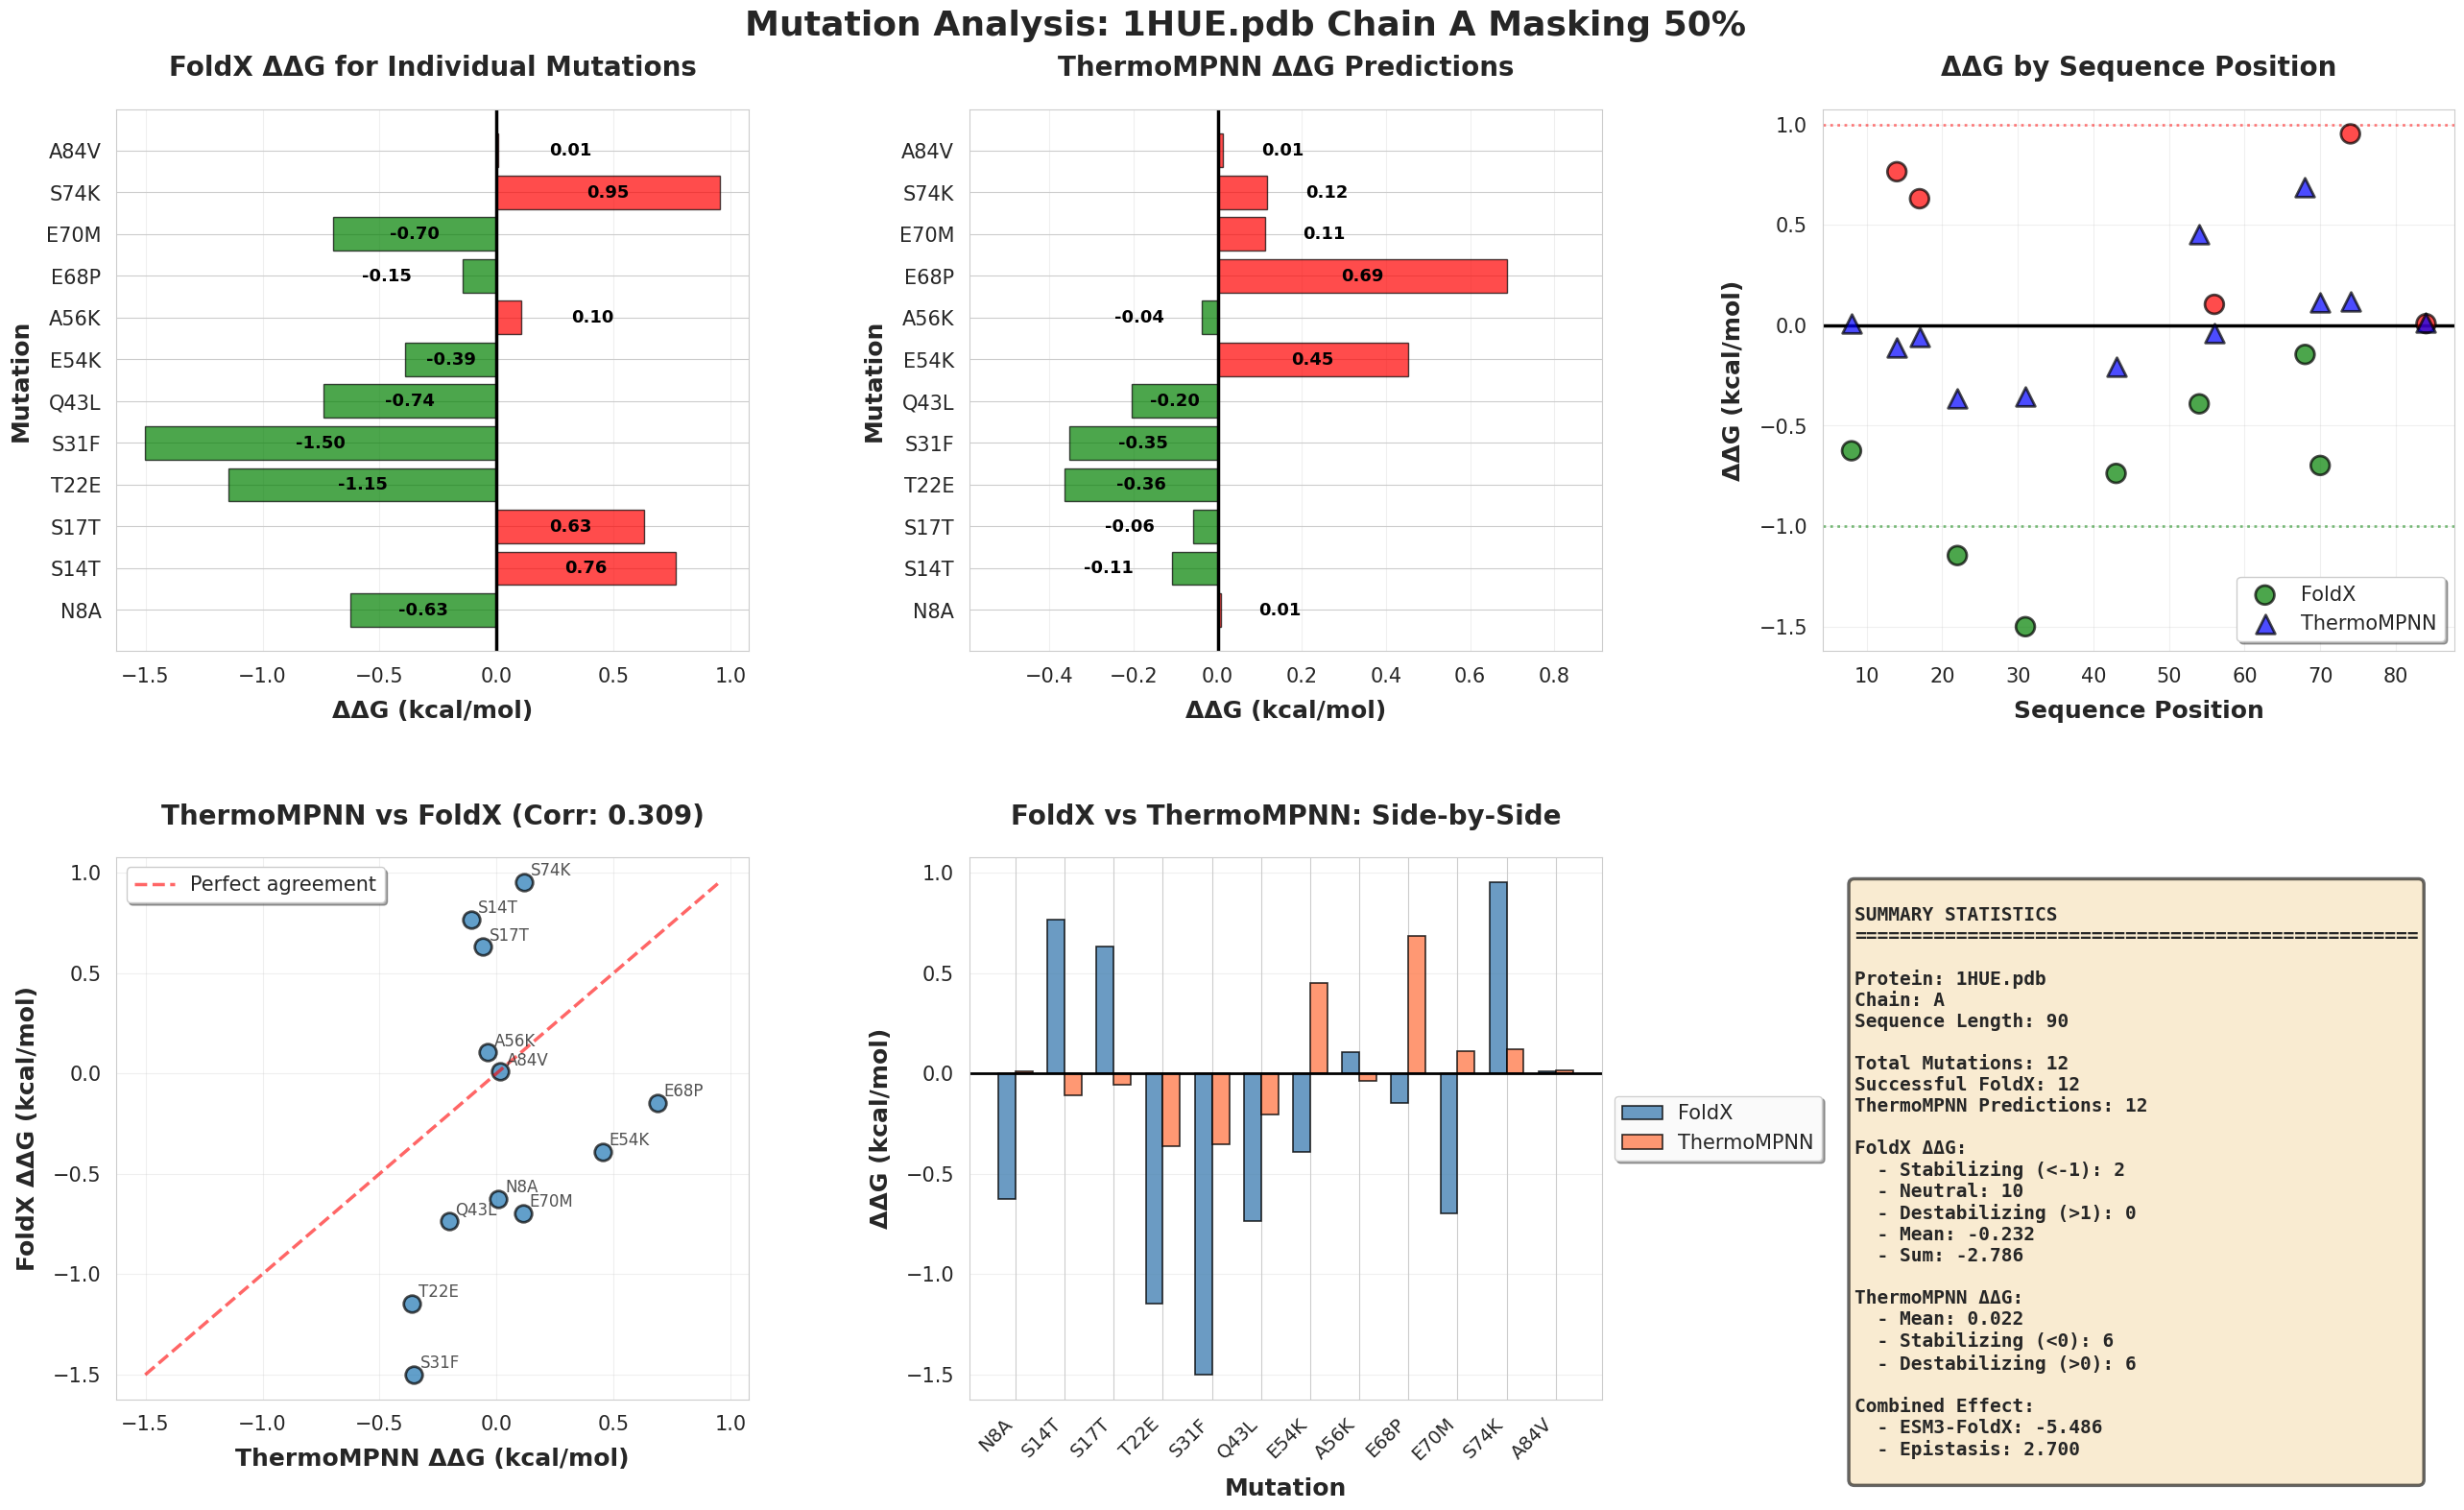

✓ Visualization complete!


In [10]:
# Check if required variables exist
if 'df_results' not in locals() or df_results.empty:
    print("⚠ ERROR: No results data available. Please run Cell 7 first to load FoldX results.")
else:
    # Define output directory for saving plots
    output_dir = "/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/plots/1HUE"
    os.makedirs(output_dir, exist_ok=True)
    
    sns.set_style("whitegrid")
    
    # Create figure with more spacing between subplots
    fig, axes = plt.subplots(2, 3, figsize=(28, 16))
    
    # Add main title with extra padding underneath
    fig.suptitle(f'Mutation Analysis: {PDB_FILENAME} Chain {CHAIN_ID} Masking 50%', 
                 fontsize=26, fontweight='bold', y=0.985)
    
    # Adjust spacing between subplots - increased top margin for title padding
    plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.08, 
                       wspace=0.35, hspace=0.38)
    
    df_valid = df_results[df_results['FoldX_ddG'].notna()]
    
    # Plot 1: FoldX ΔΔG distribution with SMART value placement
    ax = axes[0, 0]
    if len(df_valid) > 0:
        # Color bars: green for negative (stabilizing), red for positive (destabilizing)
        colors = ['green' if x < 0 else 'red' for x in df_valid['FoldX_ddG']]
        bars = ax.barh(df_valid['Mutation'], df_valid['FoldX_ddG'], color=colors, 
                      alpha=0.7, edgecolor='black', linewidth=1.0)
        
        # Get the x-axis range for threshold calculation
        x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
        threshold = x_range * 0.12  # If bar width < 12% of range, place text outside
        
        # Add value labels - SMART placement (inside if fits, outside if too small)
        for i, (idx, row) in enumerate(df_valid.iterrows()):
            value = row['FoldX_ddG']
            abs_value = abs(value)
            
            if abs_value < threshold:
                # Bar too small - place text outside
                if value >= 0:
                    x_pos = value + 0.08 * x_range
                    h_align = 'left'
                else:
                    x_pos = value - 0.08 * x_range
                    h_align = 'right'
                text_color = 'black'
            else:
                # Bar large enough - place text inside center
                x_pos = value / 2
                h_align = 'center'
                text_color = 'black'
            
            ax.text(x_pos, i, f'{value:.2f}', va='center', ha=h_align, 
                   fontsize=13, fontweight='bold', color=text_color)
        
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2.5)
        ax.set_xlabel('ΔΔG (kcal/mol)', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_ylabel('Mutation', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_title('FoldX ΔΔG for Individual Mutations', 
                    fontsize=20, fontweight='bold', pad=25)
        ax.tick_params(axis='both', which='major', labelsize=15, pad=8)
        ax.grid(axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No FoldX data available', ha='center', va='center', 
               fontsize=18, transform=ax.transAxes)
        ax.set_title('FoldX ΔΔG for Individual Mutations', 
                    fontsize=20, fontweight='bold', pad=25)
    
    # Plot 2: ThermoMPNN ΔΔG distribution with SMART value placement
    ax = axes[0, 1]
    df_thermo_valid = df_results[df_results['ThermoMPNN_ddG'].notna()]
    if len(df_thermo_valid) > 0:
        # Color bars: green for negative (stabilizing), red for positive (destabilizing)
        colors_thermo = ['green' if x < 0 else 'red' for x in df_thermo_valid['ThermoMPNN_ddG']]
        bars = ax.barh(df_thermo_valid['Mutation'], df_thermo_valid['ThermoMPNN_ddG'], 
                      color=colors_thermo, alpha=0.7, edgecolor='black', linewidth=1.0)
        
        # Get current x-axis limits and extend them for better spacing
        current_xlim = ax.get_xlim()
        x_min, x_max = current_xlim
        x_range = x_max - x_min
        
        # Extend x-axis limits by 15% on each side to prevent text collision with y-axis
        padding = x_range * 0.15
        ax.set_xlim(x_min - padding, x_max + padding)
        
        # Recalculate range after setting new limits
        x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
        threshold = x_range * 0.10  # If bar width < 10% of range, place text outside
        
        # Add value labels - SMART placement (inside if fits, outside if too small)
        for i, (idx, row) in enumerate(df_thermo_valid.iterrows()):
            value = row['ThermoMPNN_ddG']
            abs_value = abs(value)
            
            if abs_value < threshold:
                # Bar too small - place text outside
                if value >= 0:
                    x_pos = value + 0.06 * x_range
                    h_align = 'left'
                else:
                    x_pos = value - 0.06 * x_range
                    h_align = 'right'
                text_color = 'black'
            else:
                # Bar large enough - place text inside center
                x_pos = value / 2
                h_align = 'center'
                text_color = 'black'
            
            ax.text(x_pos, i, f'{value:.2f}', va='center', ha=h_align, 
                   fontsize=13, fontweight='bold', color=text_color)
        
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2.5)
        ax.set_xlabel('ΔΔG (kcal/mol)', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_ylabel('Mutation', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_title('ThermoMPNN ΔΔG Predictions', 
                    fontsize=20, fontweight='bold', pad=25)
        ax.tick_params(axis='both', which='major', labelsize=15, pad=8)
        ax.grid(axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No ThermoMPNN predictions available', 
               ha='center', va='center', fontsize=18, transform=ax.transAxes)
        ax.set_title('ThermoMPNN ΔΔG Predictions', 
                    fontsize=20, fontweight='bold', pad=25)
    
    # Plot 3: Position vs ΔΔG
    ax = axes[0, 2]
    if len(df_valid) > 0:
        colors = ['green' if x < 0 else 'red' for x in df_valid['FoldX_ddG']]
        ax.scatter(df_valid['Position'], df_valid['FoldX_ddG'], s=200, alpha=0.7, c=colors, 
                  edgecolors='black', linewidth=2.0, label='FoldX', zorder=3)
    if len(df_thermo_valid) > 0:
        ax.scatter(df_thermo_valid['Position'], df_thermo_valid['ThermoMPNN_ddG'], 
                  s=200, alpha=0.7, marker='^', c='blue', edgecolors='black', 
                  linewidth=2.0, label='ThermoMPNN', zorder=3)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2.5, zorder=1)
    ax.axhline(y=-1, color='green', linestyle=':', alpha=0.5, linewidth=2.0)
    ax.axhline(y=1, color='red', linestyle=':', alpha=0.5, linewidth=2.0)
    ax.set_xlabel('Sequence Position', fontsize=18, fontweight='bold', labelpad=10)
    ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=18, fontweight='bold', labelpad=10)
    ax.set_title('ΔΔG by Sequence Position', 
                fontsize=20, fontweight='bold', pad=25)
    ax.tick_params(axis='both', which='major', labelsize=15, pad=8)
    if len(df_valid) > 0 or len(df_thermo_valid) > 0:
        ax.legend(fontsize=15, frameon=True, shadow=True, loc='best')
    ax.grid(alpha=0.3)
    
    # Plot 4: ThermoMPNN vs FoldX scatter
    ax = axes[1, 0]
    if 'df_comparison' in locals() and len(df_comparison) > 0:
        ax.scatter(df_comparison['ThermoMPNN_ddG'], df_comparison['FoldX_ddG'], 
                  s=160, alpha=0.7, edgecolors='black', linewidth=2.0)
        min_val = min(df_comparison[['ThermoMPNN_ddG', 'FoldX_ddG']].min())
        max_val = max(df_comparison[['ThermoMPNN_ddG', 'FoldX_ddG']].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.6, 
               linewidth=2.5, label='Perfect agreement')
        for _, row in df_comparison.iterrows():
            ax.annotate(row['Mutation'], (row['ThermoMPNN_ddG'], row['FoldX_ddG']), 
                       fontsize=12, alpha=0.8, xytext=(5, 5), textcoords='offset points')
        ax.set_xlabel('ThermoMPNN ΔΔG (kcal/mol)', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_ylabel('FoldX ΔΔG (kcal/mol)', fontsize=18, fontweight='bold', labelpad=10)
        correlation = df_comparison['FoldX_ddG'].corr(df_comparison['ThermoMPNN_ddG'])
        ax.set_title(f'ThermoMPNN vs FoldX (Corr: {correlation:.3f})', 
                    fontsize=20, fontweight='bold', pad=25)
        ax.tick_params(axis='both', which='major', labelsize=15, pad=8)
        ax.legend(fontsize=15, frameon=True, shadow=True, loc='best')
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No overlapping data', ha='center', va='center', 
               fontsize=18, transform=ax.transAxes)
        ax.set_title('ThermoMPNN vs FoldX Comparison', 
                    fontsize=20, fontweight='bold', pad=25)
    
    # Plot 5: Side-by-side comparison bar plot with legend OUTSIDE on the right
    ax = axes[1, 1]
    if 'df_comparison' in locals() and len(df_comparison) > 0:
        x = np.arange(len(df_comparison))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, df_comparison['FoldX_ddG'], width, 
                       label='FoldX', alpha=0.8, color='steelblue', 
                       edgecolor='black', linewidth=1.2)
        bars2 = ax.bar(x + width/2, df_comparison['ThermoMPNN_ddG'], width, 
                       label='ThermoMPNN', alpha=0.8, color='coral', 
                       edgecolor='black', linewidth=1.2)
        
        ax.set_xlabel('Mutation', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=18, fontweight='bold', labelpad=10)
        ax.set_title('FoldX vs ThermoMPNN: Side-by-Side', 
                    fontsize=20, fontweight='bold', pad=25)
        ax.set_xticks(x)
        ax.set_xticklabels(df_comparison['Mutation'], rotation=45, ha='right', fontsize=14)
        ax.tick_params(axis='y', which='major', labelsize=15, pad=8)
        ax.tick_params(axis='x', which='major', pad=8)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=2.0)
        
        # Legend OUTSIDE plot on the right - dynamically positioned
        # loc='center left' with bbox_to_anchor=(1.02, 0.5) places it outside right edge
        # bbox_to_anchor: (x, y) where x=1.02 is just outside the right axis, y=0.5 is center
        ax.legend(fontsize=15, frameon=True, shadow=True, 
                 loc='center left', bbox_to_anchor=(1.02, 0.5),
                 borderaxespad=0, framealpha=0.95)
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No overlapping data', ha='center', va='center', 
               fontsize=18, transform=ax.transAxes)
        ax.set_title('FoldX vs ThermoMPNN: Side-by-Side', 
                    fontsize=20, fontweight='bold', pad=25)
    
    # Plot 6: Summary with LARGER font
    ax = axes[1, 2]
    ax.axis('off')
    
    # Calculate values safely BEFORE using them in f-string
    valid_foldx = df_results['FoldX_ddG'].notna()
    sum_individual_local = df_results.loc[valid_foldx, 'FoldX_ddG'].sum() if valid_foldx.any() else 0.0
    mutations_count = len(mutations) if 'mutations' in locals() else len(df_results)
    
    # Pre-calculate all conditional values
    stabilizing_count = (df_valid['FoldX_ddG'] < -1).sum() if len(df_valid) > 0 else 0
    neutral_count = ((df_valid['FoldX_ddG'] >= -1) & (df_valid['FoldX_ddG'] <= 1)).sum() if len(df_valid) > 0 else 0
    destabilizing_count = (df_valid['FoldX_ddG'] > 1).sum() if len(df_valid) > 0 else 0
    mean_foldx = df_valid['FoldX_ddG'].mean() if len(df_valid) > 0 else 0.0
    
    mean_thermo = df_thermo_valid['ThermoMPNN_ddG'].mean() if len(df_thermo_valid) > 0 else None
    mean_thermo_str = f"{mean_thermo:.3f}" if mean_thermo is not None else "N/A"
    stab_thermo = (df_thermo_valid['ThermoMPNN_ddG'] < 0).sum() if len(df_thermo_valid) > 0 else None
    stab_thermo_str = str(stab_thermo) if stab_thermo is not None else "N/A"
    destab_thermo = (df_thermo_valid['ThermoMPNN_ddG'] > 0).sum() if len(df_thermo_valid) > 0 else None
    destab_thermo_str = str(destab_thermo) if destab_thermo is not None else "N/A"
    
    summary_text = f"""
SUMMARY STATISTICS
{'='*50}

Protein: {PDB_FILENAME}
Chain: {CHAIN_ID}
Sequence Length: {len(WILDTYPE_SEQUENCE)}

Total Mutations: {mutations_count}
Successful FoldX: {valid_foldx.sum()}
ThermoMPNN Predictions: {len(df_thermo_valid)}

FoldX ΔΔG:
  - Stabilizing (<-1): {stabilizing_count}
  - Neutral: {neutral_count}
  - Destabilizing (>1): {destabilizing_count}
  - Mean: {mean_foldx:.3f}
  - Sum: {sum_individual_local:.3f}

ThermoMPNN ΔΔG:
  - Mean: {mean_thermo_str}
  - Stabilizing (<0): {stab_thermo_str}
  - Destabilizing (>0): {destab_thermo_str}

Combined Effect:
  - ESM3-FoldX: {ESM3_FOLDX_DDG:.3f}
  - Epistasis: {abs(sum_individual_local - ESM3_FOLDX_DDG):.3f}
"""
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=14, 
           verticalalignment='top', family='monospace', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6, 
                    edgecolor='black', linewidth=2.5))
    
    # Save the figure
    pdb_base = os.path.splitext(PDB_FILENAME)[0]
    plot_filename = f"mutation_analysis_{pdb_base}_chain{CHAIN_ID}_mask50.png"
    plot_path = os.path.join(output_dir, plot_filename)
    plt.savefig(plot_path, dpi=600, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {plot_path}")
    
    plt.show()
    print(f"✓ Visualization complete!")

## Cell 10: Save Results

In [11]:
output_dir = "/pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small"
os.makedirs(output_dir, exist_ok=True)

csv_filename = f"mutation_analysis_{PDB_FILENAME.replace('.pdb', '')}_chain{CHAIN_ID}_mask50.csv"
csv_path = os.path.join(output_dir, csv_filename)
df_results.to_csv(csv_path, index=False)

report_filename = f"mutation_report_{PDB_FILENAME.replace('.pdb', '')}_chain{CHAIN_ID}_mask50.txt"
report_path = os.path.join(output_dir, report_filename)

with open(report_path, 'w') as f:
    f.write(f"{'='*80}\n")
    f.write(f"MUTATION ANALYSIS REPORT\n")
    f.write(f"{'='*80}\n\n")
    f.write(f"Protein: {PDB_FILENAME}\nChain: {CHAIN_ID}\n\n")
    f.write(f"Wildtype:  {WILDTYPE_SEQUENCE}\n")
    f.write(f"Optimized: {OPTIMIZED_SEQUENCE}\n\n")
    f.write(f"Total mutations: {len(mutations)}\n")
    f.write(f"ESM3-FoldX combined ΔΔG: {ESM3_FOLDX_DDG:.3f} kcal/mol\n")
    f.write(f"Sum of individual ΔΔG: {sum_individual:.3f} kcal/mol\n")
    f.write(f"Epistasis: {abs(sum_individual - ESM3_FOLDX_DDG):.3f} kcal/mol\n\n")
    f.write(df_results.to_string(index=False))

print(f"✓ Results saved to: {csv_path}")
print(f"✓ Report saved to: {report_path}")
print(f"\n{'='*80}")
print(f"ANALYSIS COMPLETE!")
print(f"{'='*80}")

✓ Results saved to: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small/mutation_analysis_1HUE_chainA_mask50.csv
✓ Report saved to: /pscratch/sd/a/ananda/ESM3-Guided-Generation-Based-Protein-Engineering/results/FoldX_individual_mutations/small/mutation_report_1HUE_chainA_mask50.txt

ANALYSIS COMPLETE!
